# Medical Insurance Cost Prediction
## Part 1: Linear Regression Model
This notebook develops a linear regression model to predict medical insurance costs based on demographic and lifestyle factors.

In [23]:
%matplotlib inline

In [24]:
# Import necessary libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Suitability for Linear Regression

In [25]:
# Load the dataset
df = pd.read_csv('../data/insurance.csv')

## 2. Analysis Plan

In [26]:
# 2.1 Data Cleaning
print("Missing Values:\n", df.isnull().sum())
print("\nNumber of Duplicate Values before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of Duplicate Values after removal:", df.duplicated().sum())
print(f"\nNew dataset shape: {df.shape}")

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of Duplicate Values before cleaning: 1
Number of Duplicate Values after removal: 0

New dataset shape: (1337, 7)


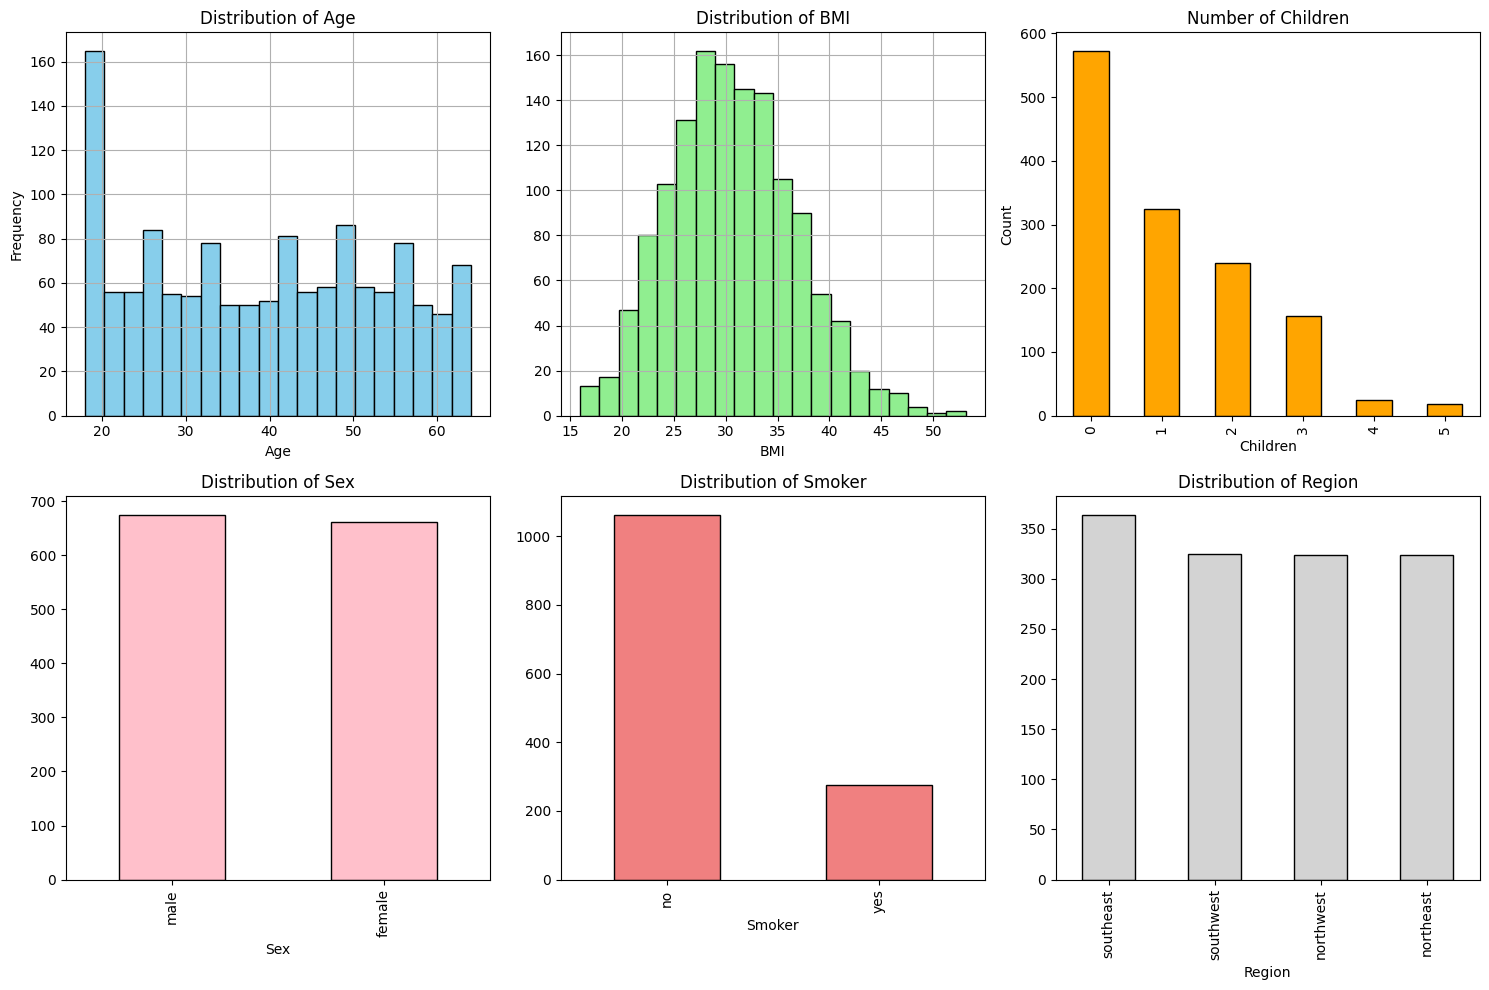

In [27]:
# 2.2 Univariate Analysis: Plot distributions of each feature
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Distribution of Age
df['age'].hist(bins=20, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Age')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Distribution of BMI
df['bmi'].hist(bins=20, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of BMI')
axes[0, 1].set_xlabel('BMI')

# Plot 3: Number of Children
df['children'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color='orange', edgecolor='black')
axes[0, 2].set_title('Number of Children')
axes[0, 2].set_xlabel('Children')
axes[0, 2].set_ylabel('Count')

# Plot 4: Distribution of Sex
df['sex'].value_counts().plot(kind='bar', ax=axes[1, 0], color='pink', edgecolor='black')
axes[1, 0].set_title('Distribution of Sex')
axes[1, 0].set_xlabel('Sex')

# Plot 5: Distribution of Smoker
df['smoker'].value_counts().plot(kind='bar', ax=axes[1, 1], color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Distribution of Smoker')
axes[1, 1].set_xlabel('Smoker')

# Plot 6: Distribution of Region
df['region'].value_counts().plot(kind='bar', ax=axes[1, 2], color='lightgrey', edgecolor='black')
axes[1, 2].set_title('Distribution of Region')
axes[1, 2].set_xlabel('Region')

plt.tight_layout()
plt.show()

### Univariate Analysis Observations:
The distributions look as expected. The age distribution is fairly uniform for adults, while BMI follows a roughly normal distribution. The dataset contains significantly more non-smokers than smokers, and the geographical regions are fairly evenly represented. No major outliers are immediately visible in these distributions.

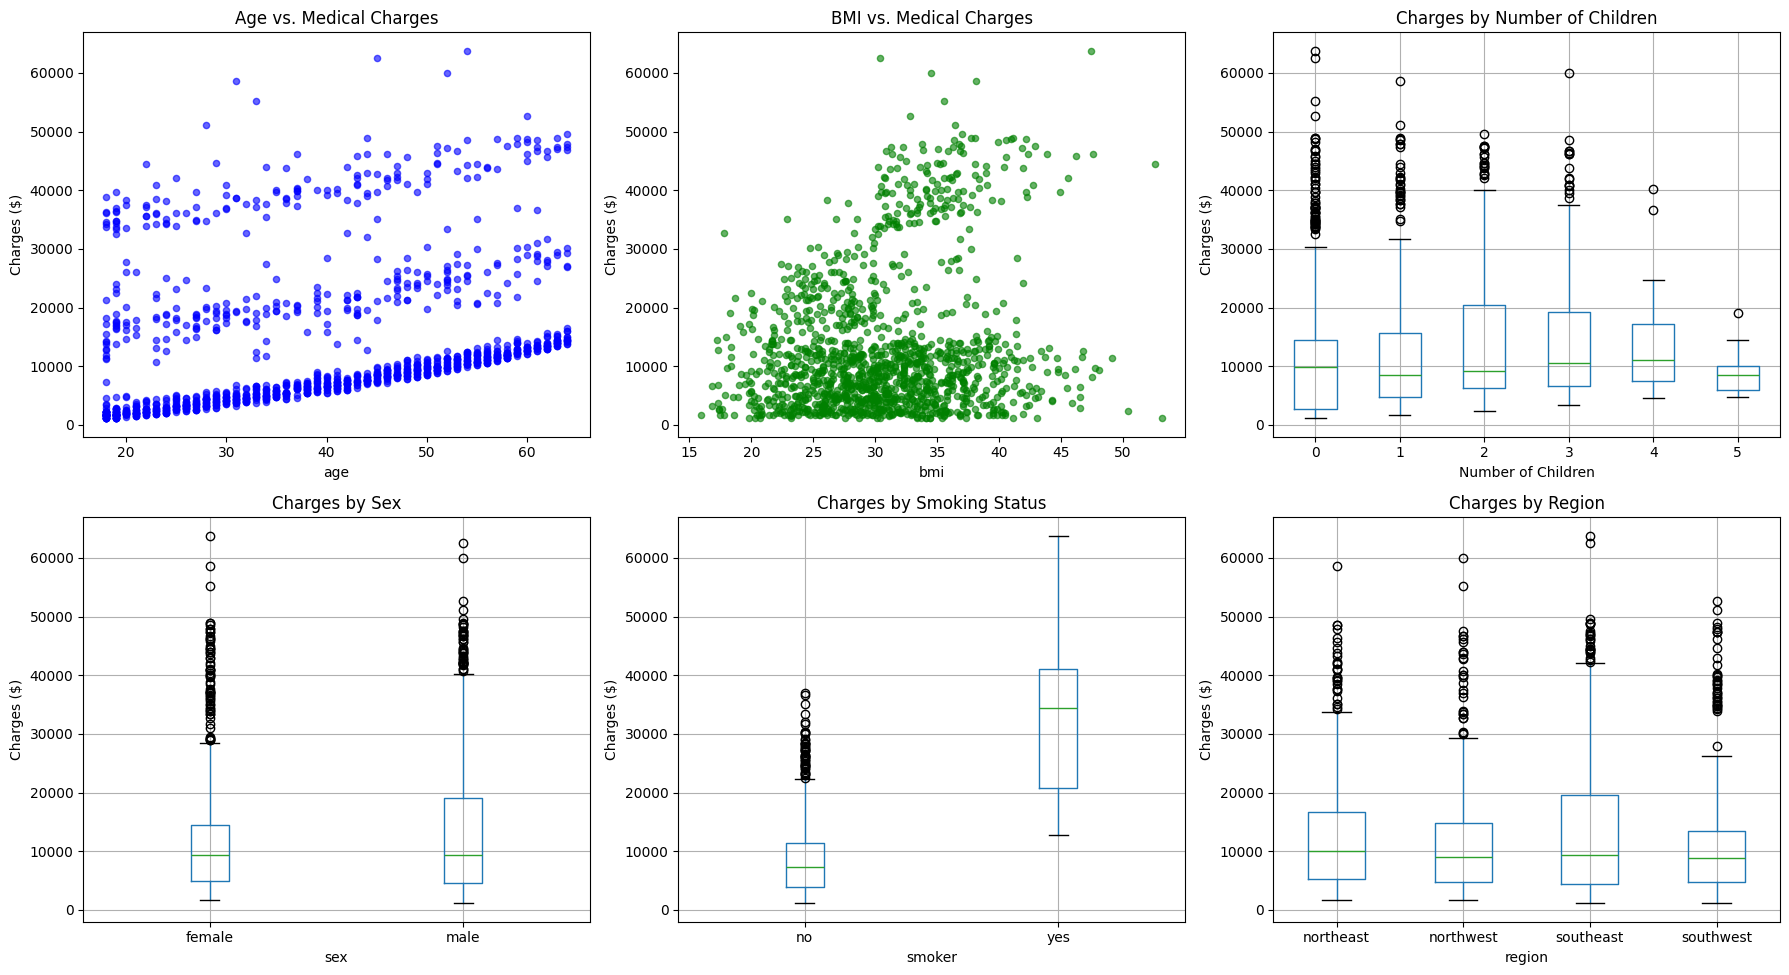

In [28]:
# 2.3 Bivariate Analysis: Analyzing relationships with 'charges'
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Scatter plot: Age vs Charges
df.plot.scatter(x='age', y='charges', ax=axes[0, 0], alpha=0.6, color='blue')
axes[0, 0].set_title('Age vs. Medical Charges')
axes[0, 0].set_ylabel('Charges ($)')

# Scatter plot: BMI vs Charges
df.plot.scatter(x='bmi', y='charges', ax=axes[0, 1], alpha=0.6, color='green')
axes[0, 1].set_title('BMI vs. Medical Charges')
axes[0, 1].set_ylabel('Charges ($)')

# Boxplot: Children vs Charges
df.boxplot(column='charges', by='children', ax=axes[0, 2])
axes[0, 2].set_title('Charges by Number of Children')
axes[0, 2].set_xlabel('Number of Children')
axes[0, 2].set_ylabel('Charges ($)')

# Boxplot: Sex vs Charges
df.boxplot(column='charges', by='sex', ax=axes[1, 0])
axes[1, 0].set_title('Charges by Sex')
axes[1, 0].set_ylabel('Charges ($)')

# Boxplot: Smoker vs Charges (This is expected to be the most significant)
df.boxplot(column='charges', by='smoker', ax=axes[1, 1])
axes[1, 1].set_title('Charges by Smoking Status')
axes[1, 1].set_ylabel('Charges ($)')

# Boxplot: Region vs Charges
df.boxplot(column='charges', by='region', ax=axes[1, 2])
axes[1, 2].set_title('Charges by Region')
axes[1, 2].set_ylabel('Charges ($)')

plt.suptitle('') # Remove the automatic title to make plots cleaner
plt.tight_layout()
plt.show()

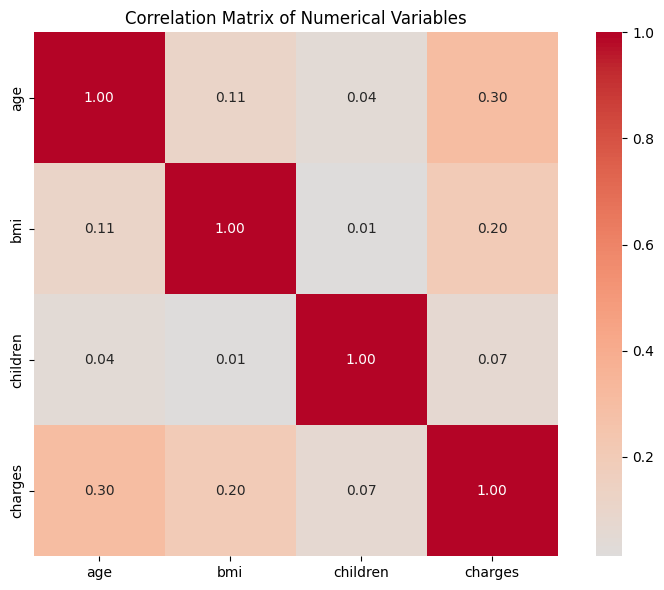

In [29]:
# 2.4 Correlation Analysis
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### EDA Findings:

*   **Age vs. Charges:** Shows a positive correlation, evident from the upward trend in the scatter plot. This justifies its inclusion as a key feature.
*   **Smoker vs. Charges:** This is the most striking relationship. The box plot reveals an enormous difference in medical costs between smokers and non-smokers. This will likely be the most important feature in our model.
*   **BMI vs. Charges:** The scatter plot shows a slight positive trend, but with considerable variance. Higher BMI seems to be associated with higher costs, particularly at the extreme end.
*   **Correlation Matrix:** Confirms the visual analysis. `age` shows the strongest correlation with `charges` among the numerical features. The low correlation between the other features suggests multicollinearity will not be a significant issue for our model.

In [30]:
# 3. Data Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Define which columns to one-hot encode
categorical_features = ['sex', 'smoker', 'region']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # This leaves the numerical columns (age, bmi, children) unchanged
)

# Apply the preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names for interpretation later
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
num_feature_names = ['age', 'bmi', 'children']
feature_names = np.concatenate([cat_feature_names, num_feature_names])

print("Preprocessing complete. Feature names:")
print(feature_names)

Preprocessing complete. Feature names:
['sex_male' 'smoker_yes' 'region_northwest' 'region_southeast'
 'region_southwest' 'age' 'bmi' 'children']


In [31]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 1069
Testing set size: 268
